# Laboratorium IV: Symulacja rozpadu promieniotwórczego

Celem tego ćwiczenia jest zasymulowanie procesu rozpadu promieniotwórczego oraz zaobserwowanie zależności pomiędzy czasem połowicznego rozpadu, stałą rozpadu i średnim czasem życia jądra.

Na początku zaimportujemy niezbędne biblioteki:

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import curve_fit

W naszej symulacji będziemy generować tablicę o zadanej długości zawierającą początkowo same jedynki, która będzie przedstawiała aktualną liczbę jąder (1 - przed rozpadem, 0 - po rozpadzie). Dla wygody, stworzymy dedykowaną funkcję:

In [5]:
def CreateNucleiArray(N = 1000):
    return np.ones(N)

print(CreateNucleiArray(100))

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


Następnie stworzymy funkcję, która symuluje rozpad promieniotwórczy oraz funkcję, która będzie zadaną ilość razy przeprowadzać proces rozpadu, symulując upływ czasu. Parametrem, który wprowadzamy jest prawdopodobieństwo rozpadu każdego jądra w pojedynczym kroku czasowym - $p$.

Druga funkcja będzie zwracała 2 tabele: jedną zawierajacą całkowitą liczbę jąder, które nie uległy rozpadowi $n_{nuclei}$ oraz liczbę rozpadów w danym kroku czasowym $n_{decays}$.

In [31]:
def Decay(Array, p = 0.01):
    n_decays = 0
    for i in range(0,len(Array)):
        if (Array[i] == 1 and np.random.rand() < p): 
            Array[i] = 0
            n_decays += 1
    return Array, n_decays

In [57]:
def DecayCounter(N = 1000, p = 0.01, nstep=100):
    n_nuclei = [N]
    n_decays = []
    m = 0
    NucArray = CreateNucleiArray(N)
    for i in range(0,nstep):
        NucArray, m = Decay(NucArray, p)
        n_decays.append(m)
        n_nuclei.append(math.fsum(NucArray))
    return n_nuclei, n_decays

Otrzymaną liczbę rozpadów będziemy następnie wykreślać w funkcji kroku czasowego:

In [58]:
def PlotDecays(n_nuclei, n_decays):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.set_xlabel('Czas [kroki]')
    ax1.set_ylabel('Liczba jąder')
    ax1.plot(n_nuclei, 'bo')
    ax1.set_title('Liczba jąder:')

    ax2.set_xlabel('Czas [kroki]')
    ax2.set_ylabel('Liczba rozpadów')
    ax2.plot(n_decays, 'ro')
    ax2.set_title('Liczba rozpadów:')

    plt.tight_layout() # Adjusts spacing so labels don't overlap
    plt.show()

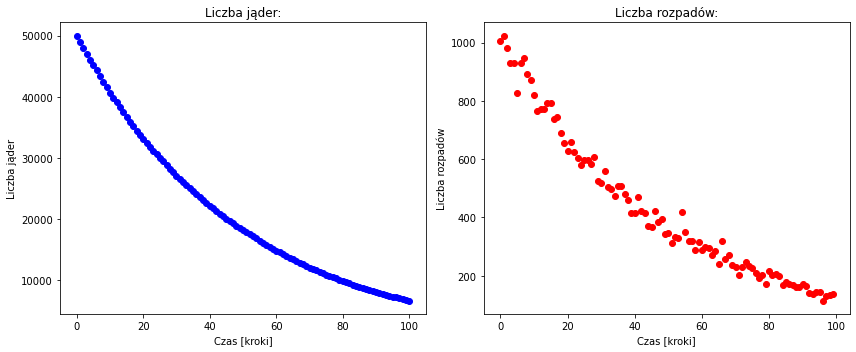

In [59]:
PlotDecays(*DecayCounter(N=50000, p =0.02, nstep=100))

Do otrzymanych danych dopasujemy jeszcze parametry równania prawa rozpadu promieniotwórczego:

liczba jąder:

$-\frac{dN}{N} = \lambda dt$

$N(t) = N_0 \exp\left({-\lambda t}\right)$

aktywność (liczba rozpadów na jednostkę czasu):

$A(t) = -\frac{dN(t)}{dt} = \lambda N_0 \exp\left({-\lambda t}\right) = A_0 \exp\left({-\lambda t}\right)$


In [91]:
def decay_law(t, N0, lmbd):
    return N0*np.exp(-lmbd*t)

def fit_decays(decay_array):
    n = len(decay_array)
    t_array = np.linspace(0, n-1, n)
    par, cov = curve_fit(decay_law, t_array, decay_array, p0 = [100, 0.01])
    
    perr = np.sqrt(np.diag(cov))

    uncertainty_N0 = perr[0]
    uncertainty_lmbd = perr[1]
    return *par, uncertainty_N0, uncertainty_lmbd

Poniżej definiujemy funkcję tworzącą wykres ilości rozpadów wraz z dopasowaniem:

In [96]:
def plot_decays_fit(n_nuclei, n_decays, save=''):
    
    N0, lmbd, std_N0, std_lmbd = fit_decays(n_nuclei)
    A0, lmbd_A, std_A0, std_lmbd_A = fit_decays(n_decays)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    t_nuc_fit = np.linspace(0,len(n_nuclei),len(n_nuclei))
    t_dec_fit = np.linspace(0,len(n_decays),len(n_decays))
    
    ax1.set_xlabel('Czas [kroki]')
    ax1.set_ylabel('Liczba jąder')
    ax1.plot(n_nuclei, 'bo')
    ax1.plot(decay_law(t_nuc_fit, N0, lmbd), linewidth=2, color='black')
    ax1.set_title('Liczba jąder:')

    ax2.set_xlabel('Czas [kroki]')
    ax2.set_ylabel('Liczba rozpadów')
    ax2.plot(decay_law(t_dec_fit, A0, lmbd_A), linewidth=2, color='black')
    ax2.plot(n_decays, 'ro')
    ax2.set_title('Liczba rozpadów:')

    plt.tight_layout() # Adjusts spacing so labels don't overlap
           
    if save != '': fig.savefig(save)
    
    plt.show() 
    print('Wyniki dopasowania: N_0 = ' + str(N0) + ' +/- ' + str(std_N0) + ', stała rozpadu: ' + str(lmbd)  + ' +/- ' + str(std_lmbd))
    print('Aktywność początkowa A_0 = ' + str(A0)  + ' +/- ' + str(std_A0) + ', stała rozpadu: ' + str(lmbd_A) + ' +/- ' + str(std_lmbd_A))

Funkcja plot_decays_fit zapisuje wykres w postaci obrazka, jeśli jako argument save otrzyma nazwę pliku:

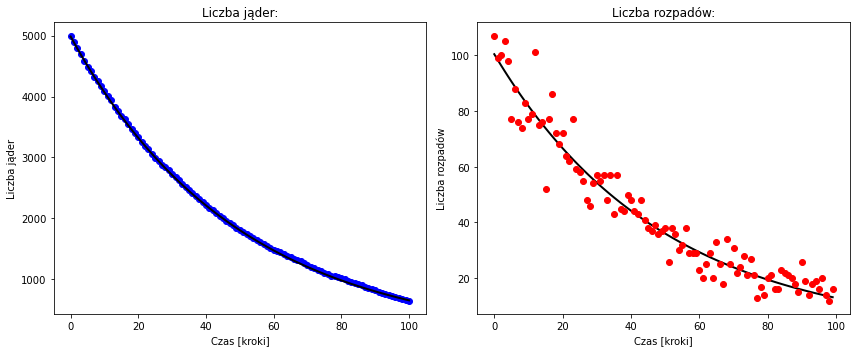

Wyniki dopasowania: N_0 = 4985.4392817149965 +/- 3.5438294885356525, stała rozpadu: 0.02011701903390031 +/- 2.3104546879219184e-05
Aktywność początkowa A_0 = 100.35044069374058 +/- 1.8203884233106329, stała rozpadu: 0.02028263216504542 +/- 0.0005948907643435486


In [99]:
plot_decays_fit(*DecayCounter(N=5000, p=0.02, nstep=100), save='wynik.png')

## Zadania do wykonania:

1. Wykonaj symulację procesu rozpadu dla 4 różnych ilości początkowych jąder pomiędzy 100 a 10000 przy stałej wartości $p$ (używając liczby kroków równej zaokrąglonemu pierwiastkowi liczby $N_0$, czyli dla $N_0$ = 100, n_step = 10, dla  $N_0$ = 3000, n_step = 55 itd.). Za każdym razem zapisz wykresy pod inną nazwą oraz spisz parametry dopasowania.

2. Wykonaj symulację dla 4 różnych wartości parametru $p$ od 0.001 do 0.1 przy $N_0$ = 10000. Zapisz wykresy i parametry dopasowania. Dla każdego przypadku oblicz aktywność początkową $A_0 = N_0 * \lambda$ i porównaj ją z wartością otrzymaną z dopasowania.

3. Określ jaki jest związek pomiędzy parametrem $p$ funkcji Decay a stałą rozpadu $\lambda$ oraz czasem połowicznego rozpadu.


### W sprawozdaniu (format PDF) umieść zestawienie otrzymanych wyników i wykresów